In [2]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchinfo import summary

from torch import nn

from tqdm.auto import tqdm
from typing import Tuple, List, Dict
import os
import sys
parent_dir = os.path.abspath('..')

c:\Users\dynam\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from Going_modular.going_modular import data_setup, engine, model_builder, utils
from Going_modular.going_modular.utils import save_model
# from Experiment_Tracking.experiment_tracking.set_seed import set_seeds


In [6]:
import config
from config import train_dir, test_dir
manual_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=config.train_dir,
    test_dir=config.test_dir, 
    transform=manual_transforms,  # e.g. data_setup.auto_transform or manual
    batch_size=32,
)


E:\Student\PyTorch\Code


In [8]:
import os 
print(parent_dir)
print(os.listdir(os.path.join(parent_dir, "Experiment_Tracking")))
# import Experiment_Tracking
# print(Experiment_Tracking.__path__) 

e:\Student\PyTorch\Code
['data', 'experiment_tracking', 'Exp_tracking_01.ipynb', 'models', 'runs', '__init__.py', '__pycache__']


In [9]:
train_dir, test_dir, class_names, train_dataloader, test_dataloader

(WindowsPath('E:/Student/PyTorch/Code/dataset/data/pizza_steak_sushi/train'),
 WindowsPath('E:/Student/PyTorch/Code/dataset/data/pizza_steak_sushi/test'),
 ['pizza', 'steak', 'sushi'],
 <torch.utils.data.dataloader.DataLoader at 0x20ac8cf1fa0>)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
image_batch, label_batch = next(iter(train_dataloader))
image,label = image_batch[0], label_batch[0]
image, label, image.shape, label, class_names[label]

(tensor([[[0.9294, 0.9373, 0.9412,  ..., 0.5647, 0.5333, 0.5020],
          [0.9255, 0.9333, 0.9373,  ..., 0.5804, 0.5333, 0.5098],
          [0.9294, 0.9373, 0.9373,  ..., 0.5804, 0.5490, 0.5255],
          ...,
          [1.0000, 1.0000, 0.9961,  ..., 0.8980, 0.9765, 0.9961],
          [0.9922, 0.9961, 1.0000,  ..., 0.6667, 0.8471, 0.9804],
          [0.9922, 0.9882, 0.9843,  ..., 0.5922, 0.6706, 0.9176]],
 
         [[0.9137, 0.9216, 0.9255,  ..., 0.4235, 0.3804, 0.3412],
          [0.9098, 0.9176, 0.9216,  ..., 0.4392, 0.3804, 0.3490],
          [0.9098, 0.9137, 0.9137,  ..., 0.4392, 0.3961, 0.3647],
          ...,
          [0.8353, 0.8392, 0.8314,  ..., 0.6784, 0.7647, 0.7922],
          [0.8275, 0.8314, 0.8392,  ..., 0.4392, 0.6235, 0.7686],
          [0.8353, 0.8314, 0.8314,  ..., 0.3765, 0.4588, 0.7098]],
 
         [[0.7294, 0.7373, 0.7529,  ..., 0.3098, 0.2667, 0.2314],
          [0.7255, 0.7333, 0.7451,  ..., 0.3216, 0.2627, 0.2314],
          [0.7216, 0.7294, 0.7373,  ...,

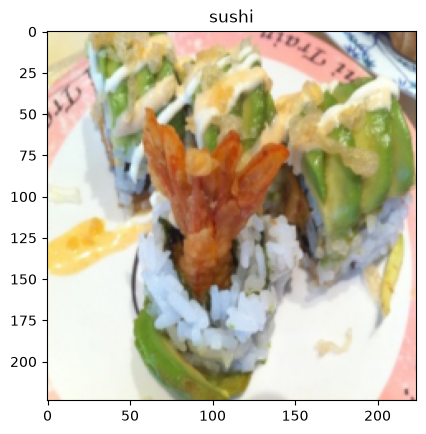

In [12]:
import matplotlib.pyplot as plt
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.show()

In [13]:
## Replicating ViT
height = 224
width = 224
color_channels = 3
patch_size = 16
number_of_patches = int((height * width) / patch_size **2)
number_of_patches 


196

In [14]:
embedding_layer_input_shape = (height, width, color_channels) #input
embedding_layer_output_shape = (number_of_patches, patch_size** 2 * color_channels) #output



print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

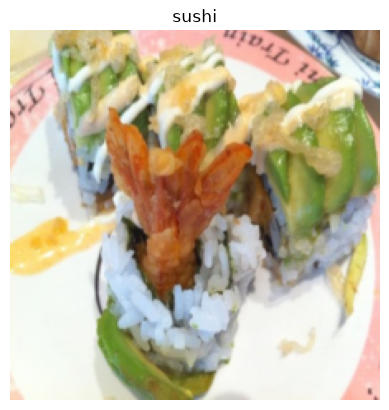

In [15]:
##  view the single image

plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

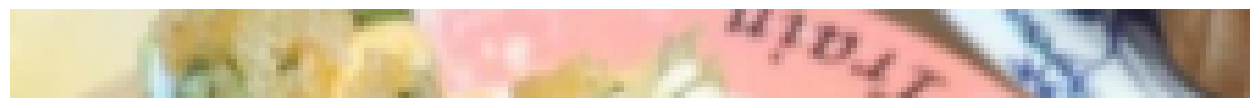

In [16]:
image_permuted = image.permute(1, 2, 0)
patch_size = 16

plt.figure(figsize = (patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
# plt.title(class_names[label])
plt.axis(False)

 Number of pathces per row : 14 
 Patch size : 16 
 Image size : 224


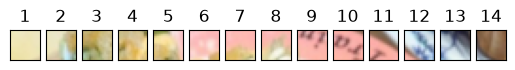

In [17]:
image_size = 224
patch_size = 16

num_patches = (image_size // patch_size) 
assert image_size % patch_size == 0, "Image size must be divisible by patch size"
print(f" Number of pathces per row : {num_patches} \n Patch size : {patch_size} \n Image size : {image_size}")
fig, axs = plt.subplots(nrows = 1, ncols = num_patches,
                        sharex = True, sharey = True,)

for i, patch in enumerate(range(0, image_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch + patch_size, :])
    axs[i].set_title(i+1)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

 Number of patches per row : 14 
 Number of patches : 196 
 Patch size : 16 
 Image size : 224


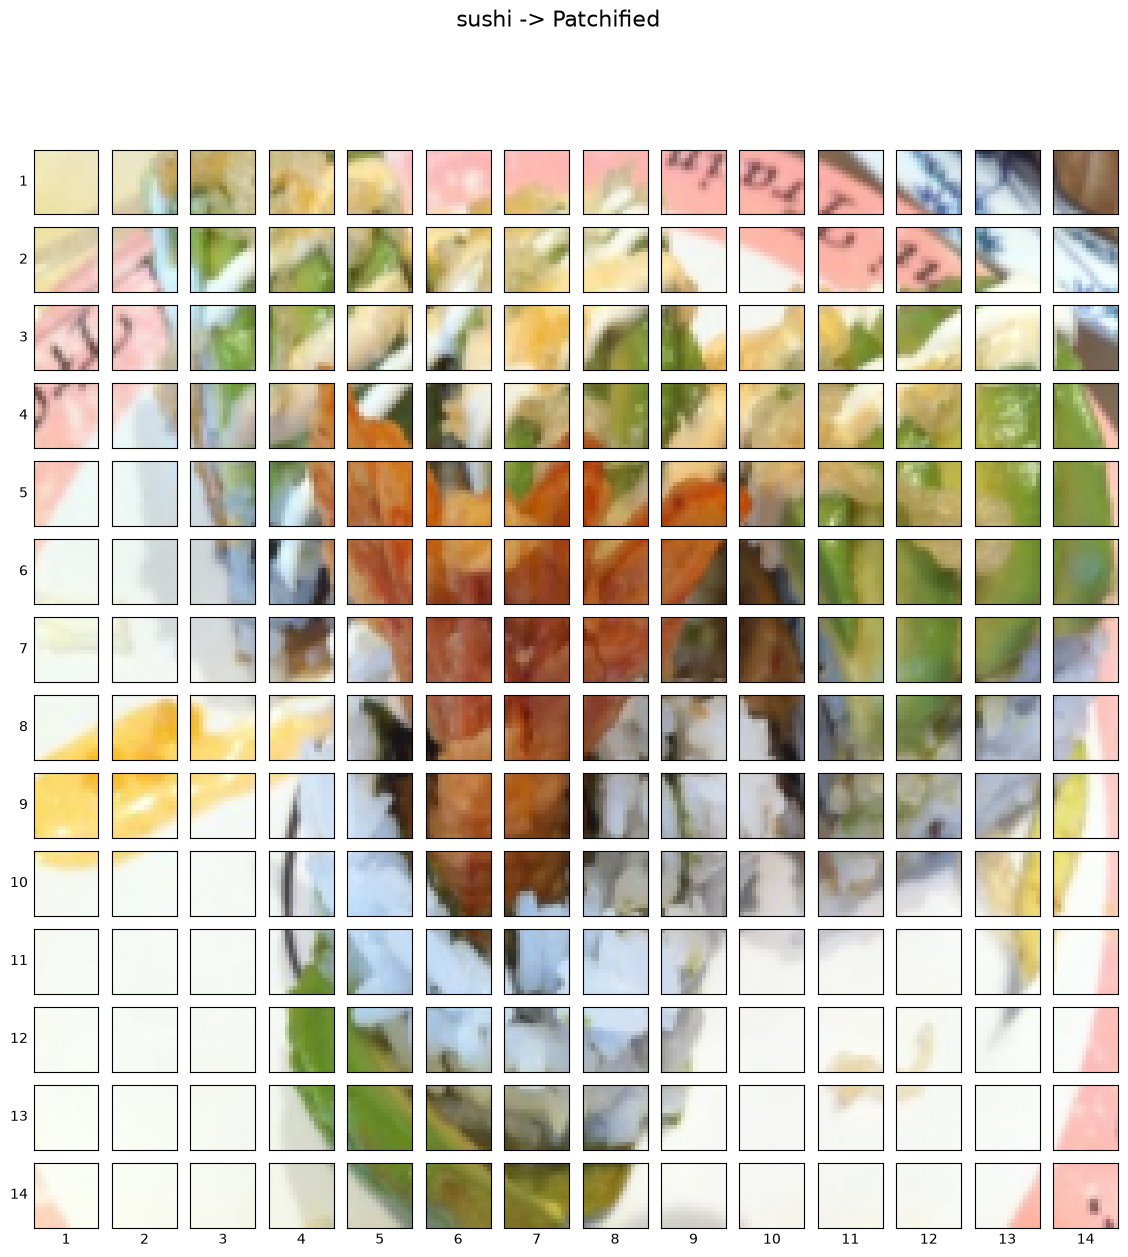

In [18]:
# setup code to plot whole image in plot

assert image_size % patch_size == 0, "Image size must be divisible by patch size"
print(f" Number of patches per row : {num_patches} \n Number of patches : {num_patches * num_patches} \n Patch size : {patch_size} \n Image size : {image_size}")

fig, axs = plt.subplots(nrows = num_patches, ncols = num_patches, figsize = (num_patches, num_patches), sharex = True, sharey = True)


# loop through height and width of the image in steps of patch size 


for i, patch_height in enumerate(range(0, image_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, image_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [19]:
#setting the kernel size and stride values to patch size
# create conv2d layer to turn image into patches olf learnable feature maps

conv2d = nn.Conv2d(in_channels = 3, out_channels = 768, kernel_size = patch_size, stride = patch_size, padding = 0)

conv2d


Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

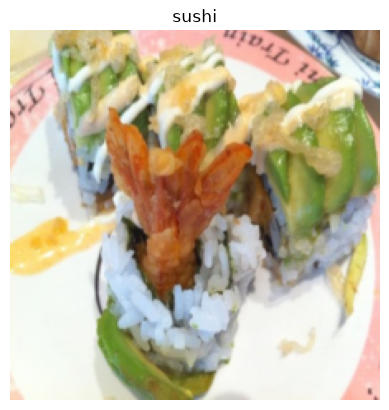

In [20]:
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

In [21]:
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


Showing random convolutional feature maps from indexes: [466, 32, 697, 254, 177]


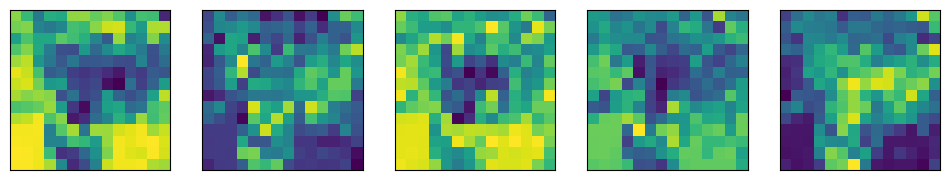

In [22]:
torch.Size([1, 768, 14, 14])
import random
random_indexes = random.sample(range(0, 758), k = 5)
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")
fig, axs = plt.subplots(nrows = 1, ncols = 5, figsize = (12,12))

for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels = [], xticks=[], yticks=[])


In [23]:
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-0.8531, -0.8678, -0.6500, -0.8196, -0.7382, -0.7713, -0.7478,
           -0.8090, -0.7724, -0.6797, -0.6422, -0.5596, -0.6223, -0.4327],
          [-0.8460, -0.8566, -0.6884, -0.6100, -0.4834, -0.6572, -0.7670,
           -0.9240, -0.8701, -0.9168, -0.7818, -0.7146, -0.5595, -0.8828],
          [-0.8105, -0.7742, -0.6348, -0.6615, -0.7303, -0.8323, -0.8292,
           -0.5987, -0.4788, -0.7489, -0.7650, -0.6221, -0.8119, -0.4370],
          [-0.8397, -0.8895, -0.5718, -0.6744, -0.5130, -0.4407, -0.5482,
           -0.5597, -0.5409, -0.7264, -0.6696, -0.5746, -0.6789, -0.6439],
          [-0.8478, -0.8466, -0.7287, -0.6444, -0.5503, -0.5059, -0.5874,
           -0.4881, -0.5577, -0.4909, -0.5341, -0.6208, -0.6495, -0.4380],
          [-0.9096, -0.8489, -0.7418, -0.4823, -0.5615, -0.4518, -0.4726,
           -0.4233, -0.4636, -0.2902, -0.5013, -0.3853, -0.5118, -0.4705],
          [-0.9109, -0.9257, -0.8150, -0.5626, -0.7127, -0.4510, -0.3989,
           -0.4674, -0.3588, -0.

In [24]:
flatten_layer = nn.Flatten(start_dim = 2, end_dim = 3)
flatten_layer(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original Image Shape: torch.Size([3, 224, 224])
Image shape after convolution: torch.Size([1, 768, 14, 14])
Image shape after flattening: torch.Size([1, 768, 196])


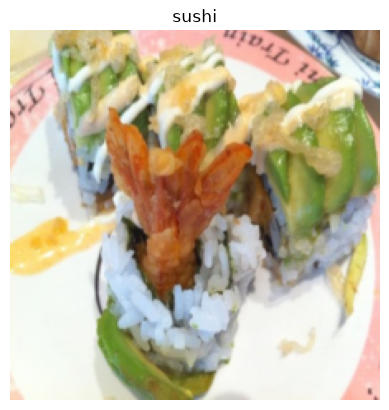

In [25]:
# Put Everything together 

plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)
print(f"Original Image Shape: {image.shape}")

image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(f"Image shape after convolution: {image_out_of_conv.shape}")


image_out_of_conv_flattened = flatten_layer(image_out_of_conv)
print(f"Image shape after flattening: {image_out_of_conv_flattened.shape}")



In [26]:
# rearrange output of flattendePlayerer

iamge_of_conv_flattened_rearranged = image_out_of_conv_flattened.permute(0, 2, 1)
iamge_of_conv_flattened_rearranged.shape

torch.Size([1, 196, 768])

(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

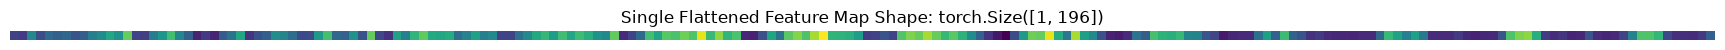

In [27]:
single_flattened_feature_map = iamge_of_conv_flattened_rearranged[:, :, 0]
plt.figure(figsize = (22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Single Flattened Feature Map Shape: {single_flattened_feature_map.shape}")
plt.axis(False)

In [28]:
# create a class called patchembedding

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels = 3, patch_size = 16, embedding_dim = 768):
        super().__init__()

        self.patcher = nn.Conv2d(in_channels = in_channels, out_channels = embedding_dim, kernel_size = patch_size, stride = patch_size, padding = 0)

        self.flatten= nn.Flatten(start_dim = 2, end_dim = 3)
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"INput image size must be divisible by patch size,  image shape: {image_resolution}, patch size: {patch_size}"

        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0, 2, 1)



In [41]:
# set_seeds(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
patchify = PatchEmbedding(in_channels = 3, patch_size = 16, embedding_dim = 768)
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Patch embedded image shape: {patch_embedded_image.shape}")




Input image shape: torch.Size([1, 3, 224, 224])
Patch embedded image shape: torch.Size([1, 196, 768])


In [42]:
rand_image_tensor = torch.randn(1, 3, 224, 224)
rand_image_tensor_bad = torch.randn(1, 4, 225, 225)
patchify(rand_image_tensor)

tensor([[[-0.3601,  0.2602, -0.7408,  ..., -1.2910, -0.2012, -0.0354],
         [-0.3405,  0.6132,  0.6626,  ..., -0.6314, -1.8604,  0.3311],
         [-0.0176, -0.2323, -0.1009,  ...,  0.1873,  0.6899, -0.5419],
         ...,
         [ 0.5333, -0.7641, -0.1217,  ...,  0.2381,  0.5565,  0.0466],
         [-0.6577, -0.0324, -0.6278,  ..., -0.1591,  0.7905,  1.4529],
         [-1.1716, -0.1617, -0.1427,  ...,  0.5600,  0.4640,  0.7539]]],
       grad_fn=<PermuteBackward0>)

In [43]:
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [44]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [45]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.9168,  0.2429, -0.2294,  ...,  0.6771, -0.4509,  0.3483],
         [-0.7427,  0.1953, -0.3559,  ...,  0.5824, -0.3451,  0.3274],
         ...,
         [-1.0077,  0.2796, -0.2795,  ...,  0.7628, -0.4584,  0.3580],
         [-0.9839,  0.1649, -0.1600,  ...,  0.7498, -0.5472,  0.3500],
         [-0.9262,  0.1364, -0.1151,  ...,  0.5843, -0.4750,  0.3103]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [46]:
# equation 1 the class token
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape 



(tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.9168,  0.2429, -0.2294,  ...,  0.6771, -0.4509,  0.3483],
          [-0.7427,  0.1953, -0.3559,  ...,  0.5824, -0.3451,  0.3274],
          ...,
          [-1.0077,  0.2796, -0.2795,  ...,  0.7628, -0.4584,  0.3580],
          [-0.9839,  0.1649, -0.1600,  ...,  0.7498, -0.5472,  0.3500],
          [-0.9262,  0.1364, -0.1151,  ...,  0.5843, -0.4750,  0.3103]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [47]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [48]:
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.0832,  1.2429,  0.7706,  ...,  1.6771,  0.5491,  1.3483],
         [ 0.2573,  1.1953,  0.6441,  ...,  1.5824,  0.6549,  1.3274],
         ...,
         [-0.0077,  1.2796,  0.7205,  ...,  1.7628,  0.5416,  1.3580],
         [ 0.0161,  1.1649,  0.8400,  ...,  1.7498,  0.4528,  1.3500],
         [ 0.0738,  1.1364,  0.8849,  ...,  1.5843,  0.5250,  1.3103]]],
       grad_fn=<AddBackward0>)


In [49]:
# set_seeds(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

patch_size = 16

print(f"Image tensor shape: {image.shape}")
height, width  = image.shape[1], image.shape[2]
x = image.unsqueeze(0)
print(f"Input image shape: {x.shape}")
patch_embedding_layer = PatchEmbedding(in_channels = 3, patch_size = patch_size, embedding_dim = 768)


patch_embedding = patch_embedding_layer(x)
print(f"Patch embedding shape: {patch_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), requires_grad=True) # make sure the embedding is learnable
print(f"class token embedding: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token prepended: {patch_embedding_class_token.shape} -> [batch_size, number_of_patches, embedding_dimension]")
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches: {number_of_patches}")
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension), requires_grad=True) # make sure it's learnable
print(f"Position embedding: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

Image tensor shape: torch.Size([3, 224, 224])
Input image shape: torch.Size([1, 3, 224, 224])
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]
class token embedding: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]
Patch embedding with class token prepended: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]
Number of patches: 196
Position embedding: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [50]:
class multiheadattention(nn.Module):
    def __init__(self, embedding_dim = 768, num_heads = 12, attn_dropout = 0):
        super().__init__()
        self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)
        self.multihead_attention = nn.MultiheadAttention(embed_dim = embedding_dim, num_heads = num_heads, dropout = attn_dropout, batch_first = True)

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attention(query = x, key = x, value = x, need_weights = False)
        return attn_output


In [51]:
multihead_attention_block = multiheadattention(embedding_dim = 768, num_heads = 12, attn_dropout = 0)
patched_image_through_msa_block = multihead_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


In [52]:
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x

In [53]:
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3

# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


In [54]:
# creating a transformer encoder block with MSA and MLP blocks

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim = 768, num_heads = 12, mlp_size = 3072, mlp_dropout = 0.1, attn_dropout = 0): 
        super().__init__()
        self.msa_block = multiheadattention(embedding_dim = embedding_dim, num_heads = num_heads, attn_dropout = attn_dropout)
        self.mlp_block = MLPBlock(embedding_dim = embedding_dim, mlp_size = mlp_size, dropout = mlp_dropout)
    def forward(self, x):
        x = self.msa_block(x) + x # residual connection
        x = self.mlp_block(x) + x # residual connection
        return x

In [55]:
transformer_encoder_block = TransformerEncoderBlock()

summary(model = transformer_encoder_block, input_size = [1, 197, 768], col_names = ["input_size", "output_size", "num_params", "trainable"], col_width = 20, row_settings = ["var_names"])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)       [1, 197, 768]        [1, 197, 768]        --                   True
├─multiheadattention (msa_block)                        [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                           [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attention)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                                  [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                           [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                                 [1, 197, 768]        [1, 197, 768]        --                   True
│  

In [56]:
# transformer encoder layer with built in pytorch layer

torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model = 768, nhead = 12, dim_feedforward= 3072, dropout = 0.1, activation = "gelu", batch_first = True, norm_first = True)

summary(model = torch_transformer_encoder_layer, input_size = [1, 197, 768], col_names = ["input_size", "output_size", "num_params", "trainable"], col_width = 20, row_settings = ["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

In [57]:
# 1. Create a ViT class that inherits from nn.Module
class ViT(nn.Module):
    """Creates a Vision Transformer architecture with ViT-Base hyperparameters by default."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 img_size:int=224, # Training resolution from Table 3 in ViT paper
                 in_channels:int=3, # Number of channels in input image
                 patch_size:int=16, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=1000): # Default for ImageNet but can customize this
        super().__init__() # don't forget the super().__init__()!

        # 3. Make the image size is divisible by the patch size
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        # 4. Calculate number of patches (height * width/patch^2)
        self.num_patches = (img_size * img_size) // patch_size**2

        # 5. Create learnable class embedding (needs to go at front of sequence of patch embeddings)
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        # 6. Create learnable position embedding
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)

        # 7. Create embedding dropout value
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # 8. Create patch embedding layer
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        # 9. Create Transformer Encoder blocks (we can stack Transformer Encoder blocks using nn.Sequential())
        # Note: The "*" means "all"
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                            num_heads=num_heads,
                                                                            mlp_size=mlp_size,
                                                                            mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

        # 10. Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )

    # 11. Create a forward() method
    def forward(self, x):

        # 12. Get batch size
        batch_size = x.shape[0]

        # 13. Create class token embedding and expand it to match the batch size (equation 1)
        class_token = self.class_embedding.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)

        # 14. Create patch embedding (equation 1)
        x = self.patch_embedding(x)

        # 15. Concat class embedding and patch embedding (equation 1)
        x = torch.cat((class_token, x), dim=1)

        # 16. Add position embedding to patch embedding (equation 1)
        x = self.position_embedding + x

        # 17. Run embedding dropout (Appendix B.1)
        x = self.embedding_dropout(x)

        # 18. Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
        x = self.transformer_encoder(x)

        # 19. Put 0 index logit through classifier (equation 4)
        x = self.classifier(x[:, 0]) # run on each sample in a batch at 0 index

        return x

In [58]:
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [59]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[0.2525, 0.8748, 1.2374]], grad_fn=<AddmmBackward0>)

In [60]:
from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                           Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                         [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)                                [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                           [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                          [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)                                [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           